# DAAN 545 Group 1: PennDOT Crash Data Statewide 2020-2024

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Set global Matplotlib parameters for white backgrounds and black text
plt.rcParams.update({
    'figure.facecolor': 'white',       # White figure background (outside the axes)
    'axes.facecolor': 'white',         # White axes background (inside the plot)
    'savefig.facecolor': 'white',      # Ensure saved figures also have a white background
    'text.color': 'black',             # Black title and general text
    'axes.labelcolor': 'black',        # Black x and y axis labels
    'xtick.color': 'black',            # Black x-axis tick marks and labels
    'ytick.color': 'black',            # Black y-axis tick marks and labels
    'axes.edgecolor': 'black'          # Black border around the plot (spines)
})

# Force Seaborn to use a crisp white background with black text
sns.set_style("white", rc={
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black"
})

## Data sourced from PennDOT Crash Data Download
https://experience.arcgis.com/experience/51809b06e7b140208a4ed6fbad964990?dlg=Window-3

### 1. Data Loading, Mapping, & Feature Translation
This section loads the cleaned dataset, establishes descriptive label mapping dictionaries, and translates raw categorical codes into human-readable text columns. It also converts the `UNBELTED` occupant count into a binary yes/no indicator column `UNBELTED_YESNO`.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# 1. Load the pre-cleaned Crash and Flags dataset for 2020-2024
merged_df = pd.read_csv("Data\\CRASH_FLAGS_2020-2024_CLEANED.csv", dtype={"CRN": str})

# Standardize column names (just to be safe)
merged_df.columns = merged_df.columns.str.upper().str.strip()

# 2. Define Mapping Dictionaries for Integer Fields
collision_type_map = {
    0: 'Non-collision',
    1: 'Rear-end',
    2: 'Head-on',
    3: 'Backing',
    4: 'Angle',
    5: 'Sideswipe (same direction)',
    6: 'Sideswipe (opposite direction)',
    7: 'Hit Fixed Object',
    8: 'Hit Non-Motorist',
    98: 'Other',
    99: 'Unknown'
}

max_severity_level_map = {
    0: 'Property Damage Only',
    1: 'Fatal',
    2: 'Suspected Serious Injury',
    3: 'Suspected Minor Injury',
    4: 'Possible Injury',
    8: 'Injury - Unknown Severity',
    9: 'Unknown if Injured'
}

road_condition_map = {
    1: 'Dry',
    2: 'Ice/Frost',
    3: 'Mud, Dirt, Gravel',
    4: 'Oil',
    5: 'Sand',
    6: 'Slush',
    7: 'Snow',
    8: 'Water (Standing/Moving)',
    9: 'Wet',
    98: 'Other',
    99: 'Unknown'
}

weather_combined_map = {
    1: 'Blowing Sand, Soil, Dirt',
    2: 'Blowing Snow',
    3: 'Clear',
    4: 'Cloudy',
    5: 'Fog, Smog, Smoke',
    6: 'Freezing Rain/Drizzle',
    7: 'Rain',
    8: 'Severe Crosswinds',
    9: 'Sleet or Hail',
    10: 'Snow',
    98: 'Other',
    99: 'Unknown'
}

# 3. Apply Mappings to Create Descriptive Columns
merged_df['COLLISION_TYPE_DESC'] = merged_df['COLLISION_TYPE'].map(collision_type_map)
merged_df['MAX_SEVERITY_LEVEL_DESC'] = merged_df['MAX_SEVERITY_LEVEL'].map(max_severity_level_map)
merged_df['ROAD_CONDITION_DESC'] = merged_df['ROAD_CONDITION'].map(road_condition_map)
merged_df['WEATHER_COMBINED_DESC'] = merged_df['WEATHER_COMBINED'].map(weather_combined_map)

# Check shape and size (UNBELTED_YESNO is loaded directly from cleaned dataset)
print(f'Shape: {merged_df.shape}')
print(f'Size: {merged_df.size}')


Shape: (560396, 32)
Size: 17932672


## Preprocessing

In [4]:
df = merged_df.copy()
df = df.drop_duplicates(subset = ["CRN"])

In [5]:
df.columns.to_list()

['CRN',
 'COLLISION_TYPE',
 'FATAL_COUNT',
 'INJURY_COUNT',
 'MAX_SEVERITY_LEVEL',
 'ROAD_CONDITION',
 'VEHICLE_COUNT',
 'AGGRESSIVE_DRIVING',
 'CELL_PHONE',
 'DISTRACTED',
 'HIT_DEER',
 'HIT_FIXED_OBJECT',
 'ILLUMINATION_DARK',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'INTERSECTION',
 'LANE_DEPARTURE',
 'MATURE_DRIVER',
 'SINGLE_VEHICLE',
 'SPEEDING',
 'STOP_CONTROLLED_INT',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'URBAN',
 'WORK_ZONE',
 'YOUNG_DRIVER',
 'WEATHER_COMBINED',
 'UNBELTED_YESNO',
 'COLLISION_TYPE_DESC',
 'MAX_SEVERITY_LEVEL_DESC',
 'ROAD_CONDITION_DESC',
 'WEATHER_COMBINED_DESC']

### 2. Preprocessing & One-Hot Encoding
To prepare the dataset for statistical modeling (PCA and K-Means):
1. **Feature Separation**: We separate binary/continuous features from multi-class categorical features.
2. **One-Hot Encoding**: Multi-class categorical variables (like `COLLISION_TYPE` or `WEATHER_COMBINED`) are converted into separate binary dummy columns (`0` or `1`) using `pd.get_dummies()`. This treats all categories as equidistant and avoids introducing artificial numerical ordering.

In [6]:
# Define numeric/binary and categorical features separately
numeric_features = [
    'AGGRESSIVE_DRIVING',
    'CELL_PHONE',
    'DISTRACTED',
    'IMPAIRED_DRIVER',
    'MATURE_DRIVER',
    'SPEEDING',
    'UNBELTED_YESNO',
    'UNDERAGE_DRNK_DRV',
    'UNLICENSED',
    'WORK_ZONE',
    'YOUNG_DRIVER',
    'URBAN',
    'INTERSECTION',
    'STOP_CONTROLLED_INT',
    'SINGLE_VEHICLE',
    'HIT_FIXED_OBJECT',
    'HIT_DEER',
    'ILLUMINATION_DARK',
    'IMPAIRED_NONMOTORIST',
    'LANE_DEPARTURE',
    'FATAL_COUNT',          # Continuous count variable (scaled to Z-score)
    'INJURY_COUNT',         # Continuous count variable (scaled to Z-score)
    'VEHICLE_COUNT'         # Continuous count variable (scaled to Z-score)
]

categorical_features = [
    'COLLISION_TYPE',
    'ROAD_CONDITION',
    'WEATHER_COMBINED',
    'MAX_SEVERITY_LEVEL'
]

numeric_cols = [c for c in numeric_features if c in df.columns]
categorical_cols = [c for c in categorical_features if c in df.columns]

# Select all features from the original dataframe
selected_cols = numeric_cols + categorical_cols
df = df[selected_cols].copy()

# One-hot encode the categorical columns
df_encoded = pd.get_dummies(df[categorical_cols], columns=categorical_cols, dtype=int)

# Combine numeric/binary columns with the one-hot encoded columns
df = pd.concat([df[numeric_cols], df_encoded], axis=1)


In [7]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 64 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   AGGRESSIVE_DRIVING    560396 non-null  int64
 1   CELL_PHONE            560396 non-null  int64
 2   DISTRACTED            560396 non-null  int64
 3   IMPAIRED_DRIVER       560396 non-null  int64
 4   MATURE_DRIVER         560396 non-null  int64
 5   SPEEDING              560396 non-null  int64
 6   UNBELTED_YESNO        560396 non-null  int64
 7   UNDERAGE_DRNK_DRV     560396 non-null  int64
 8   UNLICENSED            560396 non-null  int64
 9   WORK_ZONE             560396 non-null  int64
 10  YOUNG_DRIVER          560396 non-null  int64
 11  URBAN                 560396 non-null  int64
 12  INTERSECTION          560396 non-null  int64
 13  STOP_CONTROLLED_INT   560396 non-null  int64
 14  SINGLE_VEHICLE        560396 non-null  int64
 15  HIT_FIXED_OBJECT      560396 non-null  int64


## Dimension Reduction

### Apply at least two dimensionality reduction techniques (e.g., PCA, t‑SNE, UMAP) to your dataset.

#### PCA

#### Interpretation of the PCA Scree Plot
The Scree Plot displays the **Cumulative Explained Variance** as more Principal Components (PCs) are added.
* Each point represents the percentage of total dataset variance captured by the first $N$ components.
* The "elbow" or bending point of the curve helps identify the optimal number of components to retain. Retaining the first 10 components captures a significant proportion of the variance while reducing the dimensionality of the dataset from ~60 features down to 10.

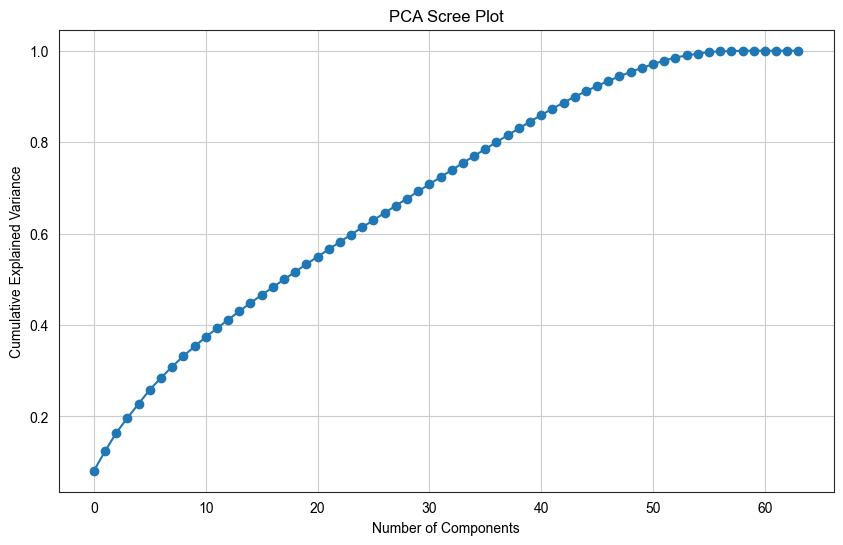

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC55,PC56,PC57,PC58,PC59,PC60,PC61,PC62,PC63,PC64
0,-3.082406,-0.313432,-0.613552,-0.124671,-0.295522,-0.916327,-0.082137,-0.492232,-0.356970,-0.327291,...,0.251909,-0.746423,-0.065366,0.151232,0.006282,-5.842295e-15,9.560136e-15,-2.845657e-15,5.584297e-15,-4.006253e-17
1,3.188283,0.435051,-0.741829,-0.800354,-0.224598,0.032094,-0.171968,1.394380,-0.469907,2.545431,...,0.135253,0.310070,0.018054,0.028593,0.004763,4.906319e-15,-9.506413e-16,-1.235546e-16,2.059335e-16,3.162779e-15
2,-1.738735,0.945556,0.119449,-0.864151,0.251661,0.020235,-0.980509,-0.802222,-1.537788,2.219774,...,-0.756275,-0.021866,-0.019569,0.124323,0.002338,-5.488144e-15,7.237254e-15,-1.844400e-15,4.279781e-16,-1.278113e-15
3,2.879463,-2.329683,0.227321,-0.197515,-0.059454,-2.199288,2.381370,-3.486968,-0.893496,2.630031,...,-0.872246,0.232547,-0.003774,0.026325,0.006871,8.876979e-14,1.124031e-13,-1.122578e-14,-1.933399e-14,2.997466e-14
4,0.326253,-1.434025,1.582390,-1.231043,0.829063,3.637450,-0.733871,1.207146,-0.515377,0.157327,...,1.192488,-0.062280,-0.017226,0.095428,-0.004496,8.000799e-15,-4.075848e-16,2.781786e-15,9.213605e-16,9.244437e-16


In [8]:
# -----------------------------
# 1. Copy dataframe
# -----------------------------
df_pca = df.copy()

# -----------------------------
# 3. Scale all features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# -----------------------------
# 4. Fit PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 5. Explained variance plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.show()

# -----------------------------
# 6. Create PCA dataframe
# -----------------------------
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca_components = pd.DataFrame(X_pca, columns=pca_cols)

df_pca_components.head()


### 4. Principal Component Loadings
The loading matrix represents the coefficients (weights) of the linear combination of original features that form each Principal Component. Loadings range from -1 to +1, showing the correlation strength and direction between each original feature and the PC.

In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,   # or your encoded feature names
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings


,AGGRESSIVE_DRIVING,CELL_PHONE,DISTRACTED,IMPAIRED_DRIVER,MATURE_DRIVER,SPEEDING,UNBELTED_YESNO,UNDERAGE_DRNK_DRV,UNLICENSED,WORK_ZONE,...,WEATHER_COMBINED_10,WEATHER_COMBINED_98,WEATHER_COMBINED_99,MAX_SEVERITY_LEVEL_0,MAX_SEVERITY_LEVEL_1,MAX_SEVERITY_LEVEL_2,MAX_SEVERITY_LEVEL_3,MAX_SEVERITY_LEVEL_4,MAX_SEVERITY_LEVEL_8,MAX_SEVERITY_LEVEL_9
PC1,-1.320079e-01,3.813641e-03,-1.967685e-02,8.059569e-02,-1.120436e-01,2.726649e-02,3.744193e-03,2.872765e-02,-1.103696e-02,-4.069428e-03,...,0.067845,-0.000283,0.068893,0.094188,0.017080,0.000846,-0.060157,-0.051378,-0.039505,0.006271
PC2,-2.681565e-01,3.978931e-02,7.078162e-02,2.749339e-02,-2.327436e-02,-2.477280e-02,-2.923032e-02,-1.501881e-03,-8.880880e-03,1.402057e-02,...,-0.110322,-0.019234,-0.081585,0.103293,0.012152,0.000536,-0.080110,-0.043831,-0.025306,-0.002529
PC3,4.779855e-02,-2.315844e-02,-2.991960e-02,-1.624088e-01,-1.103801e-02,-1.003683e-01,-1.731583e-01,-5.426965e-02,-8.033791e-03,-2.736858e-03,...,0.069619,0.005958,0.058469,0.476582,-0.179360,-0.154874,-0.294186,-0.092690,-0.149656,-0.000064
PC4,-2.442336e-02,-1.344972e-01,-2.016727e-01,-8.516058e-02,1.681315e-02,-4.977248e-02,4.649006e-03,-3.919720e-02,-9.298631e-03,-3.687428e-02,...,-0.026874,0.006135,0.119582,-0.231048,0.117263,0.068455,0.168472,0.042169,0.068882,-0.059079
PC5,5.148338e-02,-1.308967e-02,-3.042222e-02,1.040564e-01,1.127818e-02,8.358914e-02,5.610208e-02,3.259866e-02,1.241898e-02,3.202135e-03,...,-0.006740,-0.001241,0.010576,0.153948,0.641919,-0.053776,-0.212555,-0.068525,-0.087534,0.014444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC60,-0.000000e+00,-1.524745e-16,9.467578e-17,-1.266880e-16,-3.764857e-17,-2.672560e-16,3.431461e-17,1.856554e-16,-8.209850e-17,-2.923779e-16,...,-0.084468,-0.055795,-0.313091,-0.046836,-0.009240,-0.017434,-0.039646,-0.023955,-0.027257,-0.017307
PC61,1.466205e-15,-2.175587e-16,6.803624e-16,-7.498092e-16,-5.346376e-16,-2.377148e-16,1.859977e-16,-2.151422e-17,2.337832e-16,-7.507462e-17,...,0.023600,0.015589,0.087476,0.053803,0.010615,0.020027,0.045543,0.027518,0.031311,0.019881
PC62,0.000000e+00,-2.254634e-16,3.922510e-16,-9.595999e-17,-3.380457e-16,1.164018e-16,-3.241197e-16,1.103852e-17,3.173352e-16,-6.871596e-17,...,-0.045170,-0.029837,-0.167428,-0.179711,-0.035455,-0.066895,-0.152122,-0.091915,-0.104584,-0.066406
PC63,-0.000000e+00,6.430133e-17,-6.321168e-17,2.390630e-16,4.420926e-16,-2.494073e-16,2.079146e-16,2.424739e-16,-7.085635e-17,1.343565e-16,...,-0.065700,-0.043398,-0.243526,0.550993,0.108706,0.205099,0.466405,0.281810,0.320654,0.203599


In [10]:
# Programmatically interpret the meaning of each Principal Component (top 10)
n_top_components = 10
n_features_to_show = 5

def get_feature_description(feature_name, loading=1.0):
    is_positive = loading >= 0
    
    # 1. Check if the feature is a continuous count column (contains 'COUNT')
    if 'COUNT' in feature_name:
        state = "Higher" if is_positive else "Lower"
        return f"{feature_name} ({state})"
        
    # 2. Custom mappings for binary indicators depending on positive or negative loading
    custom_binary_maps = {
        'URBAN': 'URBAN: Urban Location' if is_positive else 'URBAN: Rural Location',
        'INTERSECTION': 'INTERSECTION: Crash at Intersection' if is_positive else 'INTERSECTION: Non-Intersection Crash',
        'STOP_CONTROLLED_INT': 'STOP_CONTROLLED_INT: Stop Controlled Intersection' if is_positive else 'STOP_CONTROLLED_INT: No Stop Control',
        'SINGLE_VEHICLE': 'SINGLE_VEHICLE: Single Vehicle Crash' if is_positive else 'SINGLE_VEHICLE: Multiple Vehicles',
        'HIT_FIXED_OBJECT': 'HIT_FIXED_OBJECT: Hit Fixed Object' if is_positive else 'HIT_FIXED_OBJECT: No Fixed Object Hit',
        'HIT_DEER': 'HIT_DEER: Hit Deer' if is_positive else 'HIT_DEER: No Deer Hit',
        'UNBELTED_YESNO': 'UNBELTED: Unbelted Occupant(s) Present' if is_positive else 'UNBELTED: Belted Occupants Only',
        'ILLUMINATION_DARK': 'ILLUMINATION: Dark' if is_positive else 'ILLUMINATION: Daylight',
        'LANE_DEPARTURE': 'LANE_DEPARTURE: Lane Departure' if is_positive else 'LANE_DEPARTURE: No Lane Departure'
    }
    
    if feature_name in custom_binary_maps:
        return custom_binary_maps[feature_name]
        
    # 3. Mapping of column prefixes to their respective dictionaries
    prefix_maps = {
        'COLLISION_TYPE': collision_type_map,
        'ROAD_CONDITION': road_condition_map,
        'WEATHER_COMBINED': weather_combined_map,
        'MAX_SEVERITY_LEVEL': max_severity_level_map
    }
    
    # Check if the feature is one-hot encoded (e.g., prefix_value)
    for prefix, mapping_dict in prefix_maps.items():
        if feature_name.startswith(prefix + "_"):
            suffix = feature_name[len(prefix) + 1:]
            try:
                # Try to convert key to integer
                key = int(float(suffix))
                if key in mapping_dict:
                    return f"{prefix}: {mapping_dict[key]}"
            except ValueError:
                pass
            return f"{prefix}: {suffix}"
            
    # For original binary flags (e.g., AGGRESSIVE_DRIVING)
    state = "Yes" if is_positive else "No"
    return f"{feature_name} ({state})"

def get_base_feature(feature_name):
    # List of original categorical column names that were one-hot encoded
    categorical_prefixes = [
        'COLLISION_TYPE',
        'ROAD_CONDITION',
        'WEATHER_COMBINED',
        'MAX_SEVERITY_LEVEL'
    ]
    for prefix in categorical_prefixes:
        if feature_name.startswith(prefix + "_"):
            return prefix
    return feature_name

# ==========================================================================================
# --- VERSION 1 (BEFORE): Top Contributing Features (Includes Duplicates for One-Hot Variables) ---
# ==========================================================================================
print("==========================================================================================")
print("--- VERSION 1 (BEFORE): Top Contributing Features (Includes Duplicates for One-Hot Variables) ---")
print("==========================================================================================")
for i in range(min(n_top_components, len(loadings))):
    pc_name = f'PC{i+1}'
    pc_loadings = loadings.loc[pc_name]
    
    # Sort by absolute value to get the strongest contributors
    sorted_loadings = pc_loadings.sort_values(key=abs, ascending=False)
    
    print(f"\n{pc_name} Interpretation (Top {n_features_to_show} features):")
    for feature, loading in sorted_loadings.head(n_features_to_show).items():
        direction = "(+)" if loading > 0 else "(-)"
        desc = get_feature_description(feature, loading)
        print(f"  {direction} {desc:<65} : {loading:.4f}  (Feature col: {feature})")

# ==========================================================================================
# --- VERSION 2 (AFTER): Top Contributing Features (Unique Original Features Only) ---
# ==========================================================================================
print("\n\n==========================================================================================")
print("--- VERSION 2 (AFTER): Top Contributing Features (Unique Original Features Only) ---")
print("==========================================================================================")
for i in range(min(n_top_components, len(loadings))):
    pc_name = f'PC{i+1}'
    pc_loadings = loadings.loc[pc_name]
    
    # Sort by absolute value to get the strongest contributors
    sorted_loadings = pc_loadings.sort_values(key=abs, ascending=False)
    
    print(f"\n{pc_name} Interpretation (Top {n_features_to_show} unique features):")
    seen_base_features = set()
    printed_count = 0
    
    for feature, loading in sorted_loadings.items():
        base_feature = get_base_feature(feature)
        if base_feature in seen_base_features:
            continue
            
        seen_base_features.add(base_feature)
        direction = "(+)" if loading > 0 else "(-)"
        desc = get_feature_description(feature, loading)
        print(f"  {direction} {desc:<65} : {loading:.4f}  (Feature col: {feature})")
        
        printed_count += 1
        if printed_count >= n_features_to_show:
            break


--- VERSION 1 (BEFORE): Top Contributing Features (Includes Duplicates for One-Hot Variables) ---

PC1 Interpretation (Top 5 features):
  (+) SINGLE_VEHICLE: Single Vehicle Crash                              : 0.3806  (Feature col: SINGLE_VEHICLE)
  (+) HIT_FIXED_OBJECT: Hit Fixed Object                                : 0.3731  (Feature col: HIT_FIXED_OBJECT)
  (+) COLLISION_TYPE: Hit Fixed Object                                  : 0.3731  (Feature col: COLLISION_TYPE_7)
  (+) LANE_DEPARTURE: Lane Departure                                    : 0.3285  (Feature col: LANE_DEPARTURE)
  (-) VEHICLE_COUNT (Lower)                                             : -0.3203  (Feature col: VEHICLE_COUNT)

PC2 Interpretation (Top 5 features):
  (+) ROAD_CONDITION: Dry                                               : 0.4100  (Feature col: ROAD_CONDITION_1)
  (+) COLLISION_TYPE: Other                                             : 0.3684  (Feature col: COLLISION_TYPE_98)
  (+) HIT_DEER: Hit Deer         

#### Interpretation of the PCA 2D Projection
This scatter plot projects the high-dimensional crash data onto the first two Principal Components (PC1 and PC2).
* Because the data is heavily composed of binary/one-hot encoded features, the projection naturally forms distinct geometric lines or "spokes" rather than a single continuous cloud.
* The separation and patterns indicate structural relationships among different groups of features (e.g., specific crash types or environmental patterns).

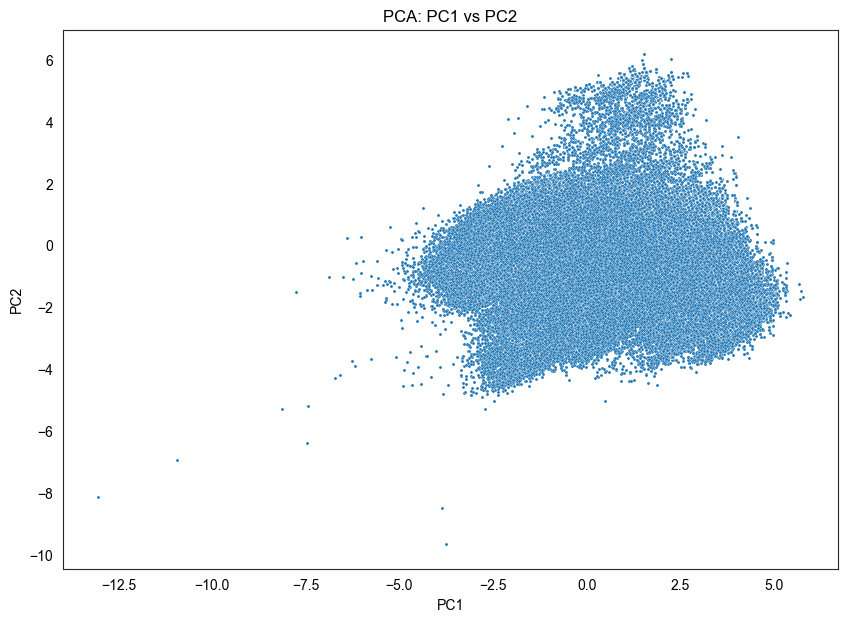

In [11]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=df_pca_components['PC1'], y=df_pca_components['PC2'], s=5)
plt.title('PCA: PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


#### T-sne

In [12]:
df_sample = df_pca_components.iloc[:, :10].sample(10000, random_state=42) # Reduced from 50k to 10k for speed

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(df_sample)



#### Interpretation of the t-SNE Projection
Unlike PCA (which is linear), t-SNE is a non-linear dimensionality reduction technique designed to preserve local structure and keep similar data points close together.
* The resulting groups or "islands" in this plot represent natural sub-groupings of crashes that share highly similar features (e.g., weather conditions, driver behaviors, or crash dynamics).

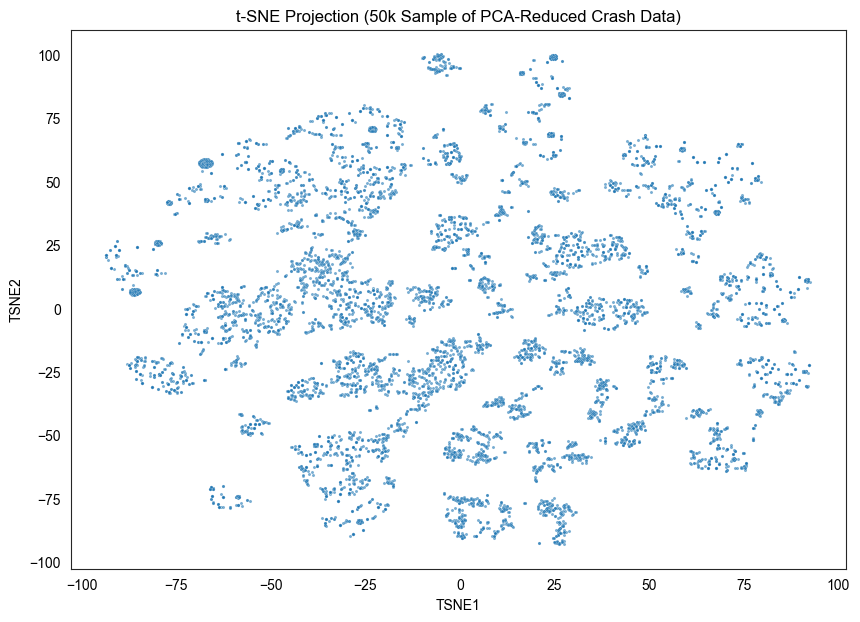

In [13]:
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_tsne['TSNE1'],
    y=df_tsne['TSNE2'],
    s=5,
    alpha=0.6
)
plt.title('t-SNE Projection (50k Sample of PCA-Reduced Crash Data)')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()

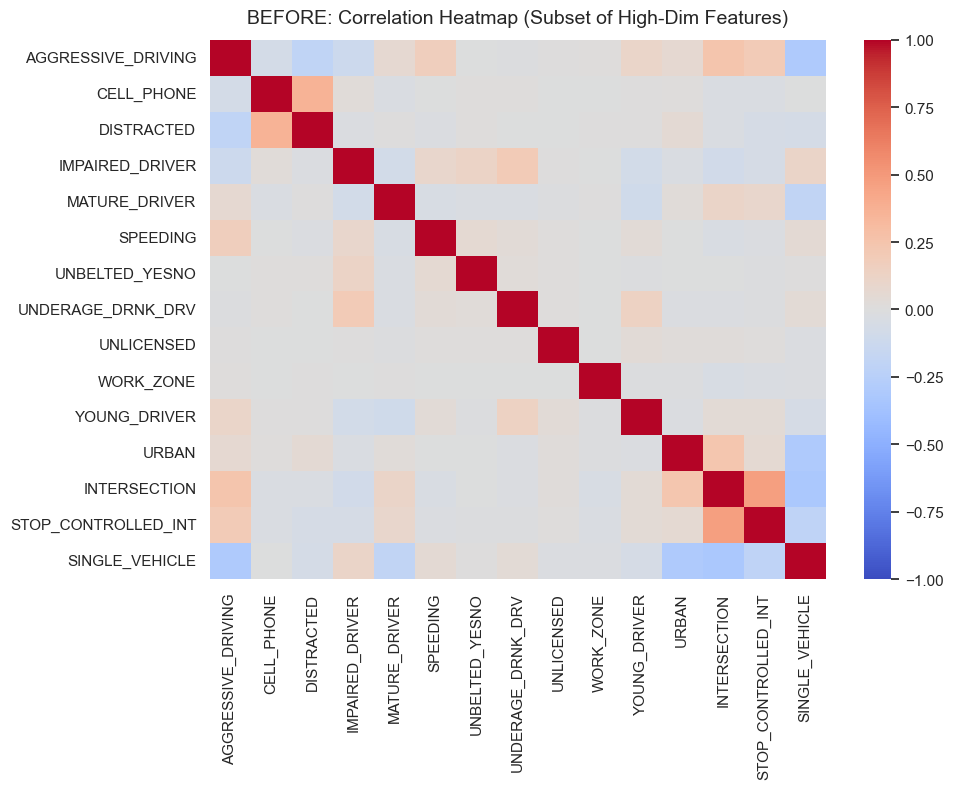

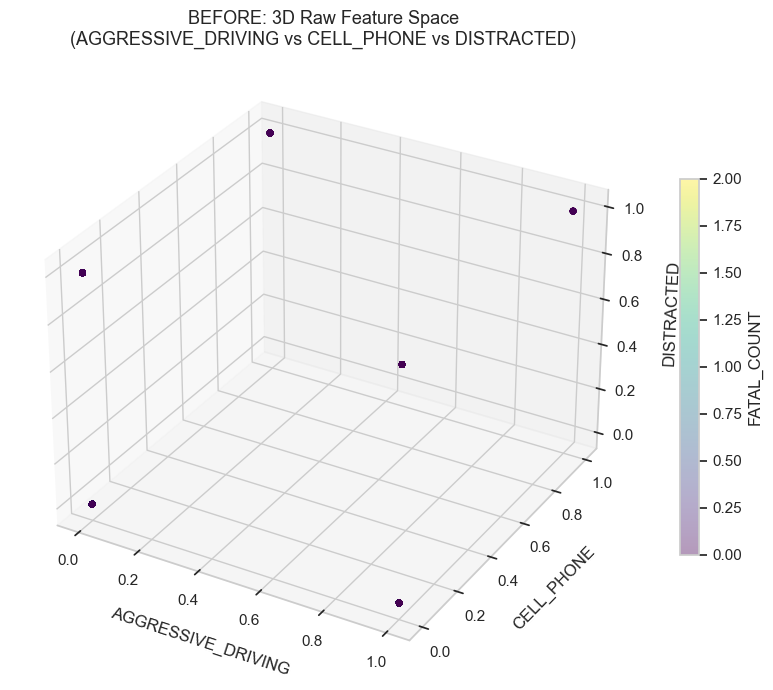

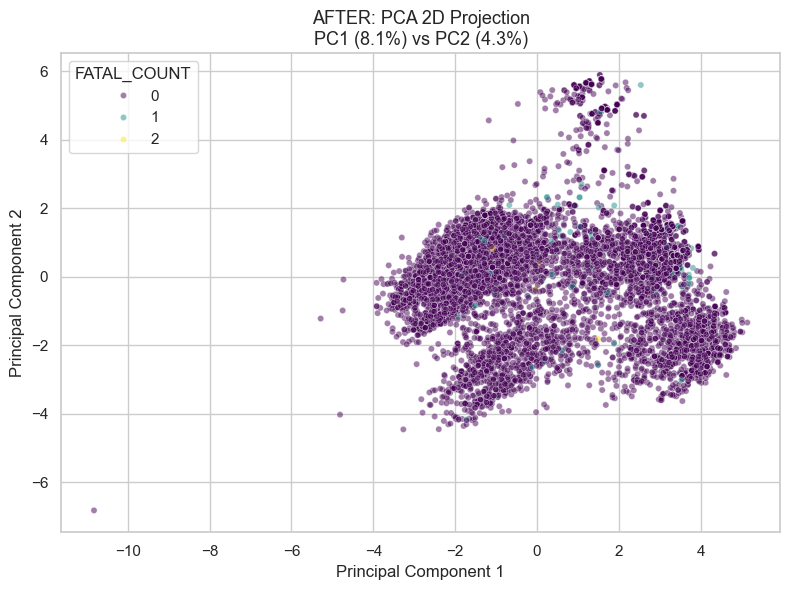

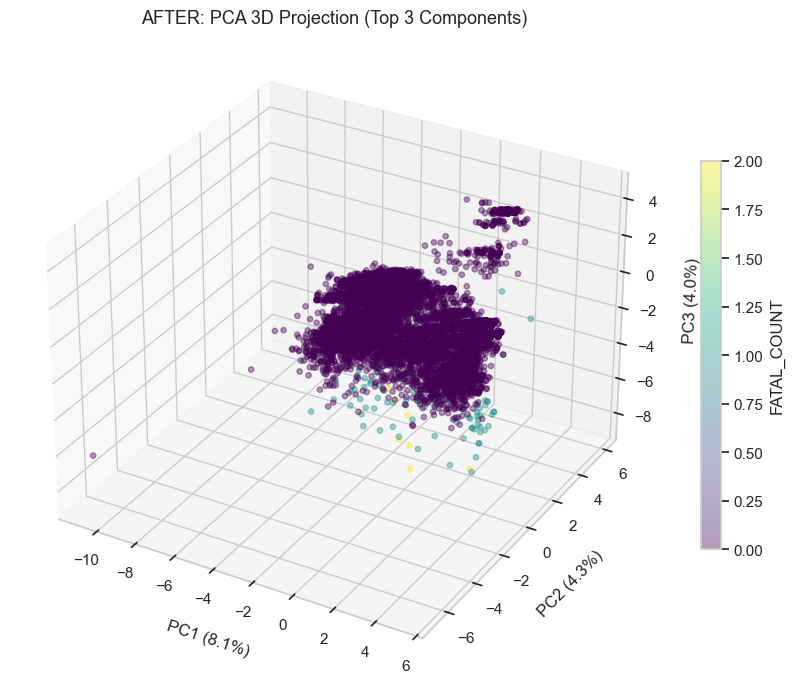

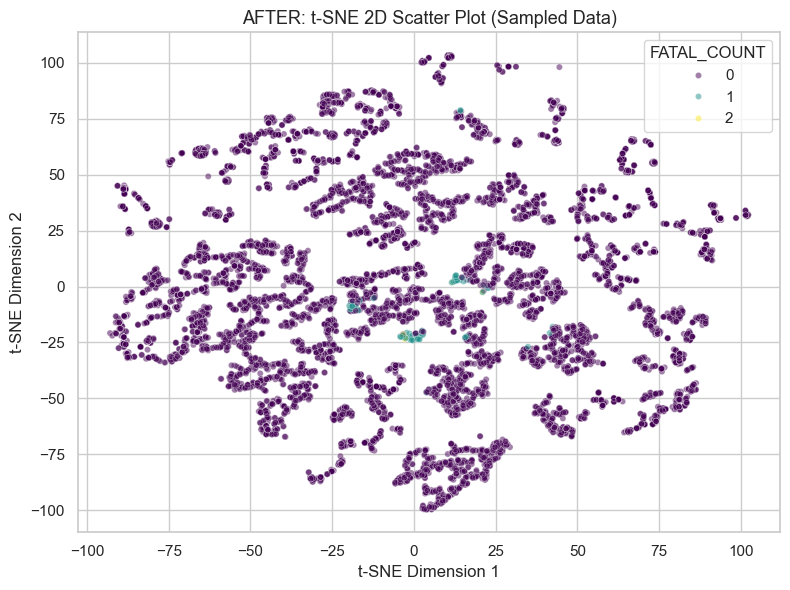

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set style for clean plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# ---------------------------------------------------------
# 0. Setup & Data Preparation
# Assume 'df_processed' contains your 64 processed numeric columns
# ---------------------------------------------------------

# Sample data for intensive visualizations (e.g., Pairplot, t-SNE)
SAMPLE_SIZE = 10000
np.random.seed(42)

df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42)

# Standardize features
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(df)
X_scaled_sample = scaler.fit_transform(df_sample)

# Color highlight feature (e.g., 'FATAL_COUNT' or 'AGGRESSIVE_DRIVING' if available)
# Replace 'MAX_SEVERITY_LEVEL' with your preferred target variable for hue
hue_col = 'FATAL_COUNT' if 'FATAL_COUNT' in df.columns else None

# =========================================================
# 1. BEFORE PLOTS: Raw High-Dimensional Structure
# =========================================================

# 1A. Correlation Heatmap (Top 15 Features)
plt.figure(figsize=(10, 8))
corr_matrix = df.iloc[:, :15].corr() # Selecting first 15 for readability
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False, cbar=True)
plt.title("BEFORE: Correlation Heatmap (Subset of High-Dim Features)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# 1B. 3D Raw Feature Scatter Plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Pick 3 original features to plot
feat_x, feat_y, feat_z = df.columns[0], df.columns[1], df.columns[2]

scatter = ax.scatter(
    df_sample[feat_x], 
    df_sample[feat_y], 
    df_sample[feat_z], 
    c=df_sample[hue_col] if hue_col else 'tab:blue',
    cmap='viridis', 
    alpha=0.4, 
    s=15
)
ax.set_xlabel(feat_x, labelpad=10)
ax.set_ylabel(feat_y, labelpad=10)
ax.set_zlabel(feat_z, labelpad=10)
ax.set_title(f"BEFORE: 3D Raw Feature Space\n({feat_x} vs {feat_y} vs {feat_z})", fontsize=13)
if hue_col:
    plt.colorbar(scatter, ax=ax, label=hue_col, shrink=0.6)
plt.tight_layout()
plt.show()

# =========================================================
# 2. AFTER PLOTS: PCA Projections (2D & 3D)
# =========================================================

# Compute PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_full = pca_3d.fit_transform(X_scaled_full)
X_pca_sample = pca_3d.transform(X_scaled_sample)

var_exp = pca_3d.explained_variance_ratio_

# 2A. PCA 2D Scatter
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca_sample[:, 0], 
    y=X_pca_sample[:, 1], 
    hue=df_sample[hue_col] if hue_col else None,
    palette='viridis', 
    alpha=0.5, 
    s=20
)
plt.title(f"AFTER: PCA 2D Projection\nPC1 ({var_exp[0]:.1%}) vs PC2 ({var_exp[1]:.1%})", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# 2B. PCA 3D Scatter
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_sample[:, 0], 
    X_pca_sample[:, 1], 
    X_pca_sample[:, 2], 
    c=df_sample[hue_col] if hue_col else 'tab:blue',
    cmap='viridis', 
    alpha=0.4, 
    s=15
)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})", labelpad=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})", labelpad=10)
ax.set_zlabel(f"PC3 ({var_exp[2]:.1%})", labelpad=10)
ax.set_title("AFTER: PCA 3D Projection (Top 3 Components)", fontsize=13)
if hue_col:
    plt.colorbar(scatter, ax=ax, label=hue_col, shrink=0.6)
plt.tight_layout()
plt.show()

# =========================================================
# 3. AFTER PLOT: t-SNE 2D Projection
# =========================================================

# Fit t-SNE on top PCA components to save runtime & preserve global structure
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca_sample) # Passing PC features into t-SNE

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=df_sample[hue_col] if hue_col else None,
    palette='viridis', 
    alpha=0.5, 
    s=20
)
plt.title("AFTER: t-SNE 2D Scatter Plot (Sampled Data)", fontsize=13)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()

## 1. "BEFORE" PLOTS: Raw High-Dimensional Structure

### Correlation Heatmap

* **Redundancy & Independence:** Most driver-behavior features (e.g., `CELL_PHONE`, `DISTRACTED`, `UNLICENSED`, `WORK_ZONE`) show weak pairwise linear correlations (near 0). However, expected domain relationships emerge—such as moderate positive correlation between `INTERSECTION` and `STOP_CONTROLLED_INT`, and weak negative correlation between `SINGLE_VEHICLE` and `INTERSECTION`.
* **Dimensionality Need:** Because pairwise correlation is generally low across many variables, no single pair of original features captures the overall structure, highlighting the necessity for multi-variable reduction techniques.

### 3D Raw Feature Scatter Plot (`AGGRESSIVE_DRIVING` vs `CELL_PHONE` vs `DISTRACTED`)

* **Sparsity & Discretization:** The datapoints are strictly locked to the corners/vertices of a 3D hypercube (values at 0.0 or 1.0).
* **Limitations:** Plotting binary indicators directly in standard 3D space produces heavy overlap and fails to reveal continuous structure, sub-clusters, or variance relative to `FATAL_COUNT`.

---

## 2. "AFTER" PLOTS: PCA Projections

### PCA 2D & 3D Projections

* **Variance Captured:** The top 3 components capture **16.4% of total variance** (PC1: 8.1%, PC2: 4.3%, PC3: 4.0%). This reflects the high dimensionality and sparse nature of binary traffic indicators across 64 features.
* **Continuous Separation:** Unlike the rigid hypercube in raw space, PCA spreads data into continuous sub-structures and distinct sub-branches, effectively unrolling the discrete combination of binary variables.
* **Fatal Crash Separation:** In the 3D PCA plot, fatal crashes (`FATAL_COUNT` > 0, teal/yellow markers) visibly separate along the lower boundary of PC3, showing that variance in lower dimensions corresponds to crash severity.

---

## 3. "AFTER" PLOTS: t-SNE 2D Projection

### Non-Linear Structure & Local Clustering

* **Distinct Sub-Clusters:** t-SNE successfully separates the continuous PCA blob into well-defined island clusters representing distinct crash profiles (e.g., combinations of environmental factors, road types, and driver behaviors).
* **Target Concentration:** Non-zero fatal crashes (`FATAL_COUNT` = 1, 2) form tight, localized groupings near the center around $(0, -25)$ rather than being randomly scattered throughout the manifold. This indicates t-SNE preserves local similarities that delineate fatal incidents from routine crashes.

---

### Summary Takeaway

| View | Linear / Global Representation | Local Clustering Capabilities |
| --- | --- | --- |
| **Raw Features** | Blocked by discrete binary boundaries (hypercube overlap). | Poor visualization without transformation. |
| **PCA** | Uncovers primary axes of variation & continuous spread ($16.4\%$ in 3D). | Shows global trends and continuous drift toward fatal crashes. |
| **t-SNE** | Distorts global distances (axes are arbitrary manifold metrics). | Excellent at isolating sub-populations and localized crash profile clusters. |

## Clustering

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 64 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   AGGRESSIVE_DRIVING    560396 non-null  int64
 1   CELL_PHONE            560396 non-null  int64
 2   DISTRACTED            560396 non-null  int64
 3   IMPAIRED_DRIVER       560396 non-null  int64
 4   MATURE_DRIVER         560396 non-null  int64
 5   SPEEDING              560396 non-null  int64
 6   UNBELTED_YESNO        560396 non-null  int64
 7   UNDERAGE_DRNK_DRV     560396 non-null  int64
 8   UNLICENSED            560396 non-null  int64
 9   WORK_ZONE             560396 non-null  int64
 10  YOUNG_DRIVER          560396 non-null  int64
 11  URBAN                 560396 non-null  int64
 12  INTERSECTION          560396 non-null  int64
 13  STOP_CONTROLLED_INT   560396 non-null  int64
 14  SINGLE_VEHICLE        560396 non-null  int64
 15  HIT_FIXED_OBJECT      560396 non-null  int64


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df.sample(56000, random_state=42))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


#### Interpretation of K-Means Evaluation Curves
These two plots are used to evaluate the quality of K-Means clustering for different cluster sizes ($K$):
* **Elbow Method (Inertia)**: Measures within-cluster sum of squares. We look for the "elbow" point where the rate of decrease in inertia slows down.
* **Silhouette Score**: Measures cluster separation and cohesion. A higher score represents better-defined clusters. The peak at $K=4$ is the mathematical optimum, while $K=6$ represents a granular compromise.

K = 2 finished.
K = 3 finished.
K = 4 finished.
K = 5 finished.
K = 6 finished.
K = 7 finished.
K = 8 finished.


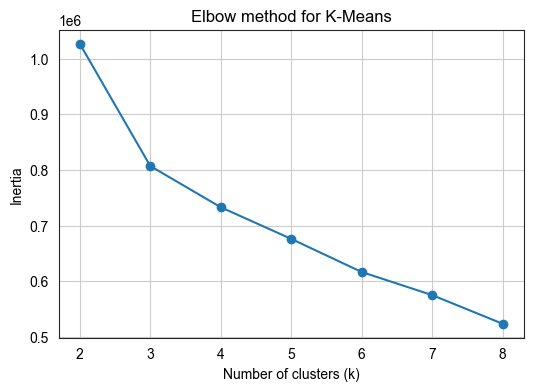

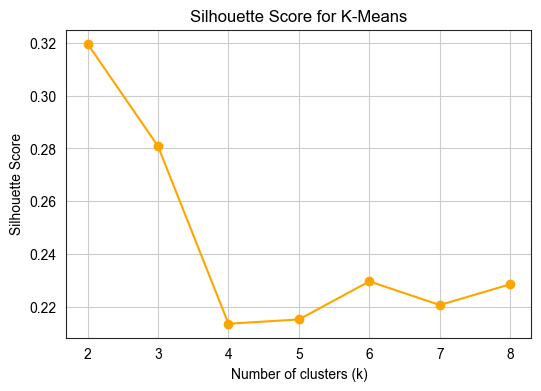

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use top 10 PCA components for clustering evaluation
X_cluster = df_pca_components.iloc[:, :10]

inertias = []
silhouette_scores = []
k_values = range(2, 9)

# To make it run fast, we fit KMeans and calculate silhouette scores on a random sample of 50,000 rows.
# Calculating silhouette scores on the full 560k dataset is O(N^2) and takes hours.
X_sample = X_cluster.sample(50000, random_state=42)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    km.fit(X_sample)
    inertias.append(km.inertia_)
    labels = km.predict(X_sample)
    # Calculate silhouette score using a sub-sample of 15,000 points to keep execution under a few seconds
    score = silhouette_score(X_sample, labels, sample_size=15000, random_state=42)
    silhouette_scores.append(score)
    print(f"K = {k} finished.")

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for K-Means')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.grid(True)
plt.show()


In [17]:
from sklearn.cluster import KMeans

# Set clusters to 6 based on evaluation results and elbow curve preferences
X_cluster = df_pca_components.iloc[:, :10]

kmeans = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans.fit_predict(X_cluster)

df_clusters = df.copy()
df_clusters['cluster_kmeans'] = labels_kmeans


#### Interpretation of K-Means Clusters in PCA Space
This plot colors the PCA projection by the assigned K-Means cluster labels ($K=6$).
* It shows how K-Means partitions the PCA space.
* Distinct colors indicate different crash profiles (e.g., urban intersection crashes, rural speeding crashes, etc.) grouped together based on centroid proximity.

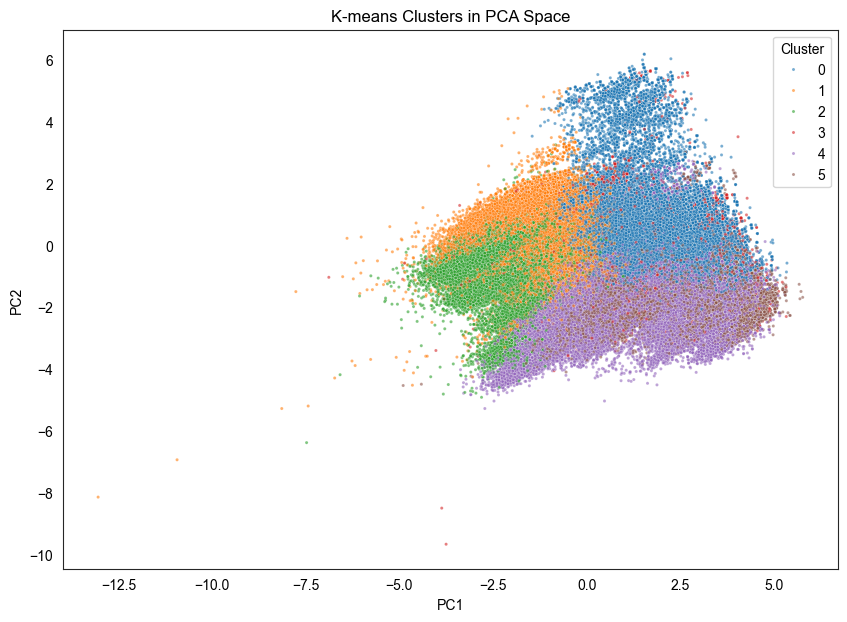

In [18]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_kmeans'],
    palette='tab10',
    s=5,
    alpha=0.6
)
plt.title('K-means Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()


### DBSCAN

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Reduce the scaled sample data to 2D PCA space to avoid curse of dimensionality
pca_temp = PCA(n_components=2)
X_scaled_2d = pca_temp.fit_transform(X_scaled)

# Try a few eps values to find a reasonable one using Manhattan distance
eps_values = [0.1, 0.3, 0.5, 0.8, 1.0]
min_samples = 50

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='manhattan')
    labels = dbscan.fit_predict(X_scaled_2d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X_scaled_2d, labels, sample_size=15000, random_state=42) # Added sample_size=15000 for speed
        print(f"eps={eps}, clusters={n_clusters}, noise={np.sum(labels == -1)}/{len(labels)}, silhouette={score:.3f}")
    else:
        print(f"eps={eps}, clusters={n_clusters}, noise={np.sum(labels == -1)}/{len(labels)}, silhouette=N/A")


eps=0.1, clusters=66, noise=17764/56000, silhouette=-0.278
eps=0.3, clusters=5, noise=934/56000, silhouette=0.140
eps=0.5, clusters=1, noise=146/56000, silhouette=N/A
eps=0.8, clusters=1, noise=16/56000, silhouette=N/A
eps=1.0, clusters=1, noise=9/56000, silhouette=N/A


In [20]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier

# 1. Sample 50,000 rows to fit DBSCAN to prevent MemoryError (bad allocation)
df_sample = df.sample(50000, random_state=42).copy()
X_cluster_sample = df_pca_components.loc[df_sample.index].iloc[:, :2]

dbscan = DBSCAN(
    eps=0.5,           # Tuned based on the 2D Manhattan parameter search
    min_samples=100,
    metric='manhattan'
)
labels_dbscan_sample = dbscan.fit_predict(X_cluster_sample)

# 2. Use a K-Nearest Neighbors Classifier to propagate labels to the entire 560k rows
knn = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn.fit(X_cluster_sample, labels_dbscan_sample)

df_clusters = df.copy()
df_clusters['cluster_dbscan'] = knn.predict(df_pca_components.iloc[:, :2])


#### Interpretation of DBSCAN Clusters in PCA Space
This plot shows the density-based clusters found by DBSCAN using Manhattan distance on the 2D PCA space.
* DBSCAN groups points that are close together in high-density areas and flags sparse, isolated points as **noise (colored in grey/labeled -1)**.
* It is useful for finding clusters of arbitrary shapes and identifying outliers.

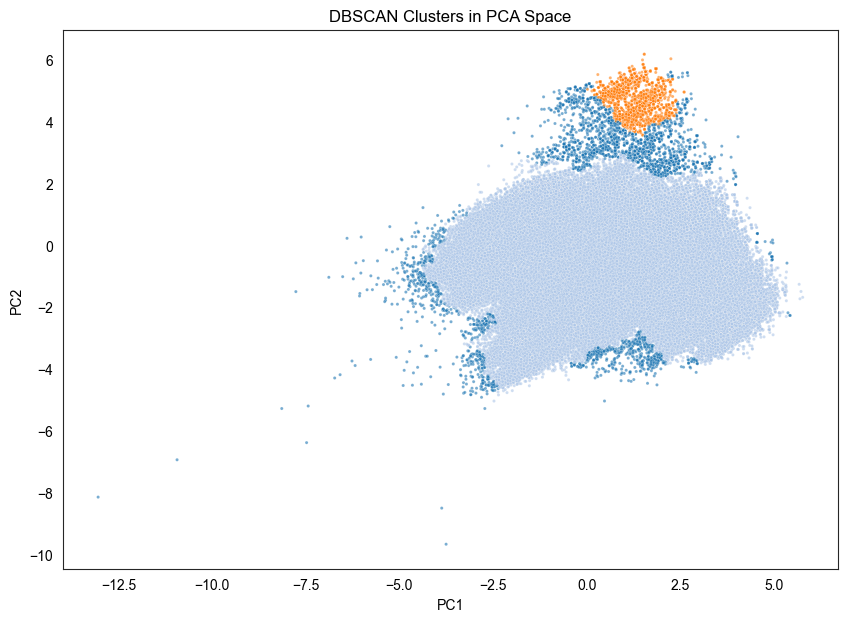

In [21]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_dbscan'],
    palette='tab20',
    s=5,
    alpha=0.6,
    legend=False
)
plt.title('DBSCAN Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Outlier Detection

### GMM on PCA components

### 7. Gaussian Mixture Model (GMM) Anomaly Detection
Gaussian Mixture Models are probabilistic models that assume all data points are generated from a mixture of a finite number of Gaussian distributions. We fit a GMM on the first 10 PCA components, compute the log-likelihood (probability density) for each crash, and flag the lowest 1% of crashes as statistical outliers/anomalies.

In [22]:
from sklearn.mixture import GaussianMixture

df_outliers = df_pca_components.copy()   # or df_pca_components.copy(), depending on what you want



X_gmm = df_pca_components.iloc[:, :10]

gmm = GaussianMixture(
    n_components=8,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_gmm)
log_probs = gmm.score_samples(X_gmm)

df_outliers['outlier_gmm'] = (log_probs < np.percentile(log_probs, 1)).astype(int)


#### Interpretation of GMM Outliers
Gaussian Mixture Models (GMM) assume that the data is generated from a mixture of several Gaussian distributions.
* This plot highlights **anomalous crashes (shown in red)**, which represent the lowest 1% probability density under the model.
* These represent rare, unusual combinations of factors (e.g. ice crashes in mid-summer, or highly unique multi-vehicle incidents).

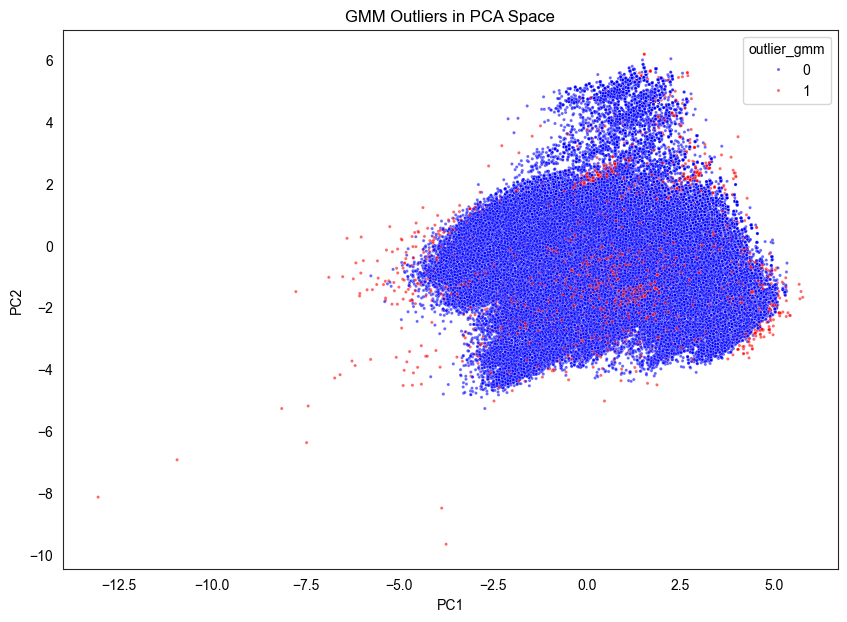

In [23]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_outliers['outlier_gmm'],
    palette={0:'blue', 1:'red'},
    s=5,
    alpha=0.6
)
plt.title('GMM Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### Isolation Forest

### 8. Isolation Forest Anomaly Detection
Isolation Forest is a tree-based anomaly detection algorithm. It isolates outliers by randomly selecting features and split values. Since anomalies require fewer splits to isolate than normal points, their path lengths in the trees are shorter. We flag the most isolated 1% of crashes as outliers.

In [23]:
from sklearn.ensemble import IsolationForest

# Use first 10 PCA components for outlier detection
X_if = df_pca_components.iloc[:, :10]

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,   # flag ~1% as outliers
    random_state=42
)

iso_labels = iso.fit_predict(X_if)

df_outliers = df.copy()
df_outliers['outlier_iso'] = iso_labels  # -1 = outlier, 1 = normal


#### Interpretation of Isolation Forest Outliers
Isolation Forest isolates anomalies by randomly partitioning feature paths. Anomalies require fewer partitions to isolate than normal points.
* **Outliers (shown in red)** represent crashes that are highly distinct from the majority of the dataset.
* It is a highly robust method for identifying unique accident scenarios.

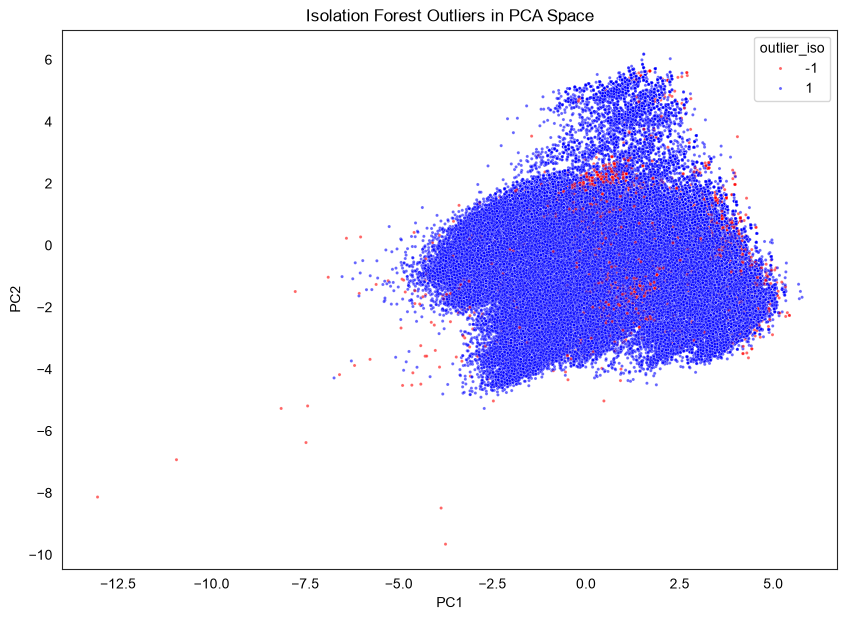

In [24]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_outliers['outlier_iso'],
    palette={1:'blue', -1:'red'},
    s=5,
    alpha=0.6
)
plt.title('Isolation Forest Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Severity Profile Analysis
Analyze the top binary and categorical features associated with each severity option to understand what a typical crash looks like for different severity levels.

In [25]:
# -----------------------------
# 1. Define Severity Options and Maps
# -----------------------------
severity_options = {
    0: 'Property Damage Only',
    1: 'Fatal',
    2: 'Suspected Serious Injury',
    3: 'Suspected Minor Injury',
    4: 'Possible Injury',
    8: 'Injury - Unknown Severity',
    9: 'Unknown if Injured'
}

# Use the original dataframe to analyze categorical variables before one-hot encoding
df_orig = merged_df.copy().drop_duplicates(subset=["CRN"])

def get_severity_feature_desc(feature_name):
    # Custom mappings for binary indicators to make them human readable in profiles
    custom_binary_maps = {
        'URBAN': 'URBAN: Urban Location',
        'INTERSECTION': 'INTERSECTION: Crash at Intersection',
        'STOP_CONTROLLED_INT': 'STOP_CONTROLLED_INT: Stop Controlled Intersection',
        'SINGLE_VEHICLE': 'SINGLE_VEHICLE: Single Vehicle Crash',
        'HIT_FIXED_OBJECT': 'HIT_FIXED_OBJECT: Hit Fixed Object',
        'HIT_DEER': 'HIT_DEER: Hit Deer',
        'UNBELTED_YESNO': 'UNBELTED: Unbelted Occupant(s) Present',
        'ILLUMINATION_DARK': 'ILLUMINATION: Dark',
        'LANE_DEPARTURE': 'LANE_DEPARTURE: Lane Departure'
    }
    if feature_name in custom_binary_maps:
        return custom_binary_maps[feature_name]
    return f"{feature_name} (Yes)"

print("--- Top Crash Profiles for each Severity Level ---")
for level, label in severity_options.items():
    group_df = df_orig[df_orig['MAX_SEVERITY_LEVEL'] == level]
    if len(group_df) == 0:
        print(f"\nMAX_SEVERITY_LEVEL {level} ({label}): No records found in dataset.\n")
        continue
        
    print(f"\n==========================================================================")
    print(f"MAX_SEVERITY_LEVEL {level}: {label} (Total Crashes: {len(group_df)})")
    print(f"==========================================================================")
    
    # Calculate occurrence percentage for each binary/numeric feature
    profile_stats = {}
    for feature in numeric_cols:
        if feature in group_df.columns:
            pct = group_df[feature].mean() * 100
            profile_stats[feature] = pct
            
    # Sort binary/numeric features by percentage descending
    sorted_profile = sorted(profile_stats.items(), key=lambda x: x[1], reverse=True)
    
    print("Top Contributing Binary Flags & Numeric Averages:")
    for feature, val in sorted_profile[:8]:
        if 'COUNT' in feature:
            print(f"  - {feature:<45} : {val/100:.2f} average per crash")
        else:
            desc = get_severity_feature_desc(feature)
            print(f"  - {desc:<45} : {val:.1f}% of crashes")
        
    # Identify top category value for each categorical variable
    print("\nTop Categorical Features:")
    for cat_col in categorical_cols:
        if cat_col != 'MAX_SEVERITY_LEVEL' and cat_col in group_df.columns:
            counts = group_df[cat_col].value_counts()
            if len(counts) > 0:
                top_val = counts.idxmax()
                top_pct = (counts.max() / len(group_df)) * 100
                
                # Map integer categories back to descriptions if mapping exists
                desc = str(top_val)
                if cat_col == 'COLLISION_TYPE' and top_val in collision_type_map:
                    desc = collision_type_map[top_val]
                elif cat_col == 'ROAD_CONDITION' and top_val in road_condition_map:
                    desc = road_condition_map[top_val]
                elif cat_col == 'WEATHER_COMBINED' and top_val in weather_combined_map:
                    desc = weather_combined_map[top_val]
                    
                print(f"  - {cat_col:<45} : {desc} ({top_pct:.1f}%)")


--- Top Crash Profiles for each Severity Level ---

MAX_SEVERITY_LEVEL 0: Property Damage Only (Total Crashes: 292834)
Top Contributing Binary Flags & Numeric Averages:
  - VEHICLE_COUNT                                 : 1.68 average per crash
  - URBAN: Urban Location                         : 65.7% of crashes
  - AGGRESSIVE_DRIVING (Yes)                      : 54.0% of crashes
  - SINGLE_VEHICLE: Single Vehicle Crash          : 42.6% of crashes
  - ILLUMINATION: Dark                            : 35.5% of crashes
  - INTERSECTION: Crash at Intersection           : 33.8% of crashes
  - HIT_FIXED_OBJECT: Hit Fixed Object            : 33.5% of crashes
  - LANE_DEPARTURE: Lane Departure                : 33.1% of crashes

Top Categorical Features:
  - COLLISION_TYPE                                : Hit Fixed Object (33.5%)
  - ROAD_CONDITION                                : Dry (73.4%)
  - WEATHER_COMBINED                              : Clear (46.8%)

MAX_SEVERITY_LEVEL 1: Fatal (Total Cra

## Custom Severity Class Profile Analysis
Analyze the top binary and categorical features associated with four custom severity classes (Low, High, Moderate, and Unknown severity) to understand common crash profiles within these groupings.

In [26]:
# -----------------------------
# 2. Define Custom Severity Classes and Groupings
# -----------------------------
severity_classes = {
    'Class 1 (Low Severity)': [0],                    # Property Damage Only
    'Class 2 (High Severity)': [1, 2],                 # Fatal, Serious Injury
    'Class 3 (Moderate Severity)': [3, 4],             # Minor Injury, Possible Injury
    'Class 4 (Unknown Severity)': [8, 9]               # Injury - Unknown Severity, Unknown if Injured
}

print("--- Top Crash Profiles for Custom Severity Classes ---")
for class_name, levels in severity_classes.items():
    group_df = df_orig[df_orig['MAX_SEVERITY_LEVEL'].isin(levels)]
    if len(group_df) == 0:
        print(f"\n{class_name}: No records found in dataset.\n")
        continue
        
    print(f"\n==========================================================================")
    print(f"{class_name} (Total Crashes: {len(group_df)})")
    print(f"==========================================================================")
    
    # Calculate occurrence percentage for each binary/numeric feature
    profile_stats = {}
    for feature in numeric_cols:
        if feature in group_df.columns:
            pct = group_df[feature].mean() * 100
            profile_stats[feature] = pct
            
    # Sort binary/numeric features by percentage descending
    sorted_profile = sorted(profile_stats.items(), key=lambda x: x[1], reverse=True)
    
    print("Top Contributing Binary Flags & Numeric Averages:")
    for feature, val in sorted_profile[:8]:
        if 'COUNT' in feature:
            print(f"  - {feature:<45} : {val/100:.2f} average per crash")
        else:
            desc = get_severity_feature_desc(feature)
            print(f"  - {desc:<45} : {val:.1f}% of crashes")
        
    # Identify top category value for each categorical variable
    print("\nTop Categorical Features:")
    for cat_col in categorical_cols:
        if cat_col != 'MAX_SEVERITY_LEVEL' and cat_col in group_df.columns:
            counts = group_df[cat_col].value_counts()
            if len(counts) > 0:
                top_val = counts.idxmax()
                top_pct = (counts.max() / len(group_df)) * 100
                
                # Map integer categories back to descriptions if mapping exists
                desc = str(top_val)
                if cat_col == 'COLLISION_TYPE' and top_val in collision_type_map:
                    desc = collision_type_map[top_val]
                elif cat_col == 'ROAD_CONDITION' and top_val in road_condition_map:
                    desc = road_condition_map[top_val]
                elif cat_col == 'WEATHER_COMBINED' and top_val in weather_combined_map:
                    desc = weather_combined_map[top_val]
                    
                print(f"  - {cat_col:<45} : {desc} ({top_pct:.1f}%)")


--- Top Crash Profiles for Custom Severity Classes ---

Class 1 (Low Severity) (Total Crashes: 292834)
Top Contributing Binary Flags & Numeric Averages:
  - VEHICLE_COUNT                                 : 1.68 average per crash
  - URBAN: Urban Location                         : 65.7% of crashes
  - AGGRESSIVE_DRIVING (Yes)                      : 54.0% of crashes
  - SINGLE_VEHICLE: Single Vehicle Crash          : 42.6% of crashes
  - ILLUMINATION: Dark                            : 35.5% of crashes
  - INTERSECTION: Crash at Intersection           : 33.8% of crashes
  - HIT_FIXED_OBJECT: Hit Fixed Object            : 33.5% of crashes
  - LANE_DEPARTURE: Lane Departure                : 33.1% of crashes

Top Categorical Features:
  - COLLISION_TYPE                                : Hit Fixed Object (33.5%)
  - ROAD_CONDITION                                : Dry (73.4%)
  - WEATHER_COMBINED                              : Clear (46.8%)

Class 2 (High Severity) (Total Crashes: 25589)
Top Con

## Thematic Feature Category Analysis
Analyze the overall dataset characteristics by grouping features into four main themes: Human + Driver Behavior, Environmental + Temporal Factors, Roadway + Infrastructure, and Crash Dynamics. This displays the most common characteristics across all Pennsylvania crashes for each theme.

In [27]:
# -----------------------------
# 3. Define Thematic Categories of Features
# -----------------------------
feature_categories = {
    'Cat 1: Human + Driver Behavior': {
        'binary': [
            'AGGRESSIVE_DRIVING', 'CELL_PHONE', 'DISTRACTED', 'IMPAIRED_DRIVER',
            'MATURE_DRIVER', 'SPEEDING', 'UNBELTED_YESNO', 'UNDERAGE_DRNK_DRV',
            'UNLICENSED', 'YOUNG_DRIVER', 'FATAL_COUNT', 'INJURY_COUNT'
        ],
        'categorical': []
    },
    'Cat 2: Environmental + Temporal Factors': {
        'binary': ['ILLUMINATION_DARK'],
        'categorical': ['ROAD_CONDITION', 'WEATHER_COMBINED']
    },
    'Cat 3: Roadway + Infrastructure Characteristics': {
        'binary': ['URBAN', 'INTERSECTION', 'STOP_CONTROLLED_INT', 'WORK_ZONE'],
        'categorical': []
    },
    'Cat 4: Crash Dynamics': {
        'binary': ['SINGLE_VEHICLE', 'HIT_FIXED_OBJECT', 'HIT_DEER', 'LANE_DEPARTURE', 'IMPAIRED_NONMOTORIST', 'VEHICLE_COUNT'],
        'categorical': ['COLLISION_TYPE']
    }
}

print("--- Overall Top Characteristics by Thematic Feature Category ---")
for cat_name, groupings in feature_categories.items():
    print(f"\n==========================================================================")
    print(f"{cat_name}")
    print(f"==========================================================================")
    
    # 1. Process Binary/Numeric flags
    binary_stats = {}
    for feature in groupings['binary']:
        if feature in df_orig.columns:
            pct = df_orig[feature].mean() * 100
            # Note: For counts, mean rate is printed, for binary it is percentage
            binary_stats[feature] = pct
            
    if binary_stats:
        sorted_binaries = sorted(binary_stats.items(), key=lambda x: x[1], reverse=True)
        print("Top Binary & Numeric Flags (Overall Average/Presence Rate):")
        for feature, val in sorted_binaries:
            desc = get_severity_feature_desc(feature)
            if 'COUNT' in feature:
                print(f"  - {feature:<45} : {val/100:.2f} average per crash")
            else:
                print(f"  - {desc:<45} : {val:.1f}% of all crashes")
            
    # 2. Process Categorical distributions
    if groupings['categorical']:
        if groupings['binary']:
            print("") # line break
        print("Top Categorical Factors (Overall Mode):")
        for cat_col in groupings['categorical']:
            if cat_col in df_orig.columns:
                counts = df_orig[cat_col].value_counts()
                if len(counts) > 0:
                    top_val = counts.idxmax()
                    top_pct = (counts.max() / len(df_orig)) * 100
                    
                    # Map integer categories back to descriptions
                    desc = str(top_val)
                    if cat_col == 'COLLISION_TYPE' and top_val in collision_type_map:
                        desc = collision_type_map[top_val]
                    elif cat_col == 'ROAD_CONDITION' and top_val in road_condition_map:
                        desc = road_condition_map[top_val]
                    elif cat_col == 'WEATHER_COMBINED' and top_val in weather_combined_map:
                        desc = weather_combined_map[top_val]
                        
                    print(f"  - {cat_col:<45} : {desc} ({top_pct:.1f}%)")


--- Overall Top Characteristics by Thematic Feature Category ---

Cat 1: Human + Driver Behavior
Top Binary & Numeric Flags (Overall Average/Presence Rate):
  - INJURY_COUNT                                  : 0.59 average per crash
  - AGGRESSIVE_DRIVING (Yes)                      : 55.4% of all crashes
  - YOUNG_DRIVER (Yes)                            : 18.2% of all crashes
  - MATURE_DRIVER (Yes)                           : 17.9% of all crashes
  - UNBELTED: Unbelted Occupant(s) Present        : 10.5% of all crashes
  - DISTRACTED (Yes)                              : 10.3% of all crashes
  - IMPAIRED_DRIVER (Yes)                         : 9.2% of all crashes
  - SPEEDING (Yes)                                : 3.5% of all crashes
  - CELL_PHONE (Yes)                              : 1.5% of all crashes
  - FATAL_COUNT                                   : 0.01 average per crash
  - UNDERAGE_DRNK_DRV (Yes)                       : 0.4% of all crashes
  - UNLICENSED (Yes)                    